<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T3/semana-01/blob/main/Ciclo_de_Vida_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CÉLULA 1: Importando nossa "Caixa de Ferramentas" para Dados
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("Ferramentas carregadas! Prontos para brincar com os dados.")

# ---

Ferramentas carregadas! Prontos para brincar com os dados.


In [ ]:
# CÉLULA 2: ETAPA 1 E 2 - COLETA E COMPREENSÃO (Simulando o Banco de Dados da Fábrica)
# Vamos criar dados fictícios de uma esteira de perfumes do Boticário
dados_fabrica = {
    'ID_Frasco': [101, 102, 103, 104, 105, 106],
    'Volume_ml': [100.5, 99.8, np.nan, 100.1, 50.0, 100.2], # np.nan é um dado "vazio/perdido"
    'Sensor_Cor': ['Aprovado', 'Aprovado', 'Reprovado', 'Aprovado', 'Aprovado', 'Erro_Leitura'],
    'Status_Final': ['OK', 'OK', 'FALHA', 'OK', 'FALHA', 'FALHA']
}

# Transformamos isso em uma tabela (DataFrame)
tabela = pd.DataFrame(dados_fabrica)

print("--- DADOS BRUTOS (Do jeito que chegam do sistema) ---")
display(tabela) # O display() deixa a tabela bonita no Colab

# ---


--- DADOS BRUTOS (Do jeito que chegam do sistema) ---


,ID_Frasco,Volume_ml,Sensor_Cor,Status_Final
0,101,100.5,Aprovado,OK
1,102,99.8,Aprovado,OK
2,103,NaN,Reprovado,FALHA
3,104,100.1,Aprovado,OK
4,105,50.0,Aprovado,FALHA
5,106,100.2,Erro_Leitura,FALHA


In [ ]:
# CÉLULA 3: A DOR DO DIA A DIA (O que o computador vê de errado?)
print("\nResumo do que temos de errado na tabela (Valores Vazios):")
print(tabela.isnull().sum())

# ---


Resumo do que temos de errado na tabela (Valores Vazios):
ID_Frasco       0
Volume_ml       1
Sensor_Cor      0
Status_Final    0
dtype: int64


In [ ]:
# CÉLULA 4: ETAPA 3 - PREPARAÇÃO DOS DADOS (A Mágica da Engenharia de Dados)
print("Iniciando a Limpeza dos Dados...\n")

# 1. O frasco 103 não tem a medição de volume. Vamos preencher com a média dos outros!
media_volume = tabela['Volume_ml'].mean()
tabela['Volume_ml'] = tabela['Volume_ml'].fillna(media_volume)

# 2. O frasco 105 tem só 50ml (metade do perfume). O sistema marcou "Aprovado" na cor, mas é uma anomalia!
# 3. O frasco 106 deu erro no sensor.
# Vamos arrumar esses textos estranhos e padronizar.
tabela['Sensor_Cor'] = tabela['Sensor_Cor'].replace('Erro_Leitura', 'Reprovado')

print("--- DADOS LIMPOS E PREPARADOS PARA A INTELIGÊNCIA ARTIFICIAL ---")
display(tabela)

# ---


Iniciando a Limpeza dos Dados...

--- DADOS LIMPOS E PREPARADOS PARA A INTELIGÊNCIA ARTIFICIAL ---


,ID_Frasco,Volume_ml,Sensor_Cor,Status_Final
0,101,100.50,Aprovado,OK
1,102,99.80,Aprovado,OK
2,103,90.12,Reprovado,FALHA
3,104,100.10,Aprovado,OK
4,105,50.00,Aprovado,FALHA
5,106,100.20,Reprovado,FALHA



Gerando Gráfico de Qualidade para a Diretoria...


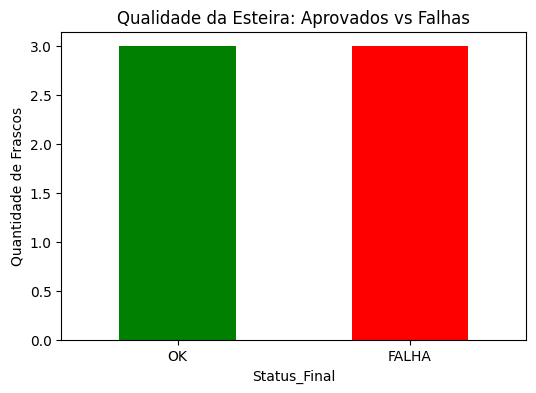


Conclusão para o Negócio: Temos 50% de perda nesta amostra. Precisamos de um modelo de Machine Learning urgente na esteira!


In [ ]:

# CÉLULA 5: ETAPA 4 - EXTRAINDO VALOR (Análise de Mercado/Negócio)
# Agora que os dados estão limpos, podemos gerar insights para a diretoria.
print("\nGerando Gráfico de Qualidade para a Diretoria...")

contagem_status = tabela['Status_Final'].value_counts()

# Criando um gráfico simples
plt.figure(figsize=(6,4))
contagem_status.plot(kind='bar', color=['green', 'red'])
plt.title('Qualidade da Esteira: Aprovados vs Falhas')
plt.ylabel('Quantidade de Frascos')
plt.xticks(rotation=0)
plt.show()

print("\nConclusão para o Negócio: Temos 50% de perda nesta amostra. Precisamos de um modelo de Machine Learning urgente na esteira!")